## Observation Planning for proposals 

CTAO will conduct observations based on competitive proposals requesting time. 
This tutorial will enable you to complete the sections of an observation proposal concerning the observation parameters and the technical justification.

To start with, we assume that you already know a) the science case for gamma-ray emission, b) a specific target located on the sky, and c) the anticipated gamma-ray flux. 

We will now address the following questions:
1. Is the source visible by CTAO-N/CTAO-S?
2. How much time do I need to reach a 5$\sigma$ detection?
3. What role do the zenith angle and Night Sky Background play? 
4. How do I determine a good observation strategy?
5. What total observation time should be requested? 

### 4: pointing

In this notebook we investigate how to determine a reasonable pointing strategy. 


In [1]:
#First import some useful packages
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle

from IPython.display import display

from gammapy.maps import MapAxis, RegionGeom, Map
from gammapy.modeling.models import GaussianSpatialModel,SkyModel,PowerLawSpectralModel,PointSpatialModel

from regions import CircleSkyRegion

%matplotlib inline

In [2]:
#Let's take our model from before: 

#1es 0229+200 from doi:10.3847/1538-4365/ab5b98 
model_pl = PowerLawSpectralModel(
    index=2.6,
    amplitude=6.91e-12 * u.Unit("cm-2 s-1 TeV-1"),
    reference=0.521 * u.TeV,
)

# coordinates: l,b=(152.9700,-36.6126)

# point = PointSpatialModel(lon_0="152.970 deg", lat_0="-36.613 deg", frame="galactic")

#For illustrative processes, we consider a gaussian in the galactic plane with 0.3 deg size

gauss = GaussianSpatialModel(lon_0="152.970 deg", lat_0="0 deg", sigma="0.3 deg", frame="galactic")

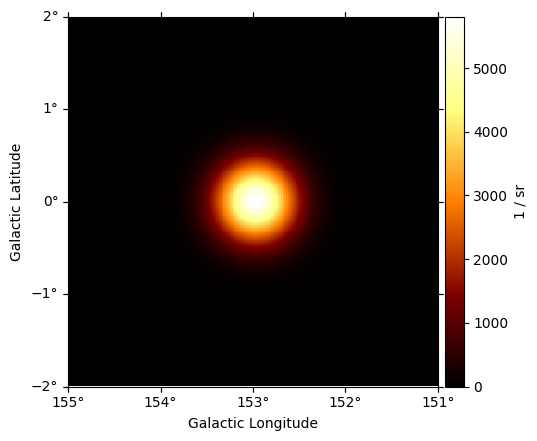

In [3]:
m = Map.create(skydir=(153, 0), width=(4, 4), binsz=0.02, frame="galactic")
m.quantity = gauss.evaluate_geom(m.geom)
m.plot(add_cbar=True)
plt.show()


In [4]:
#Define wobble positions and LST FoV radius ~2deg
center = SkyCoord(153, 0, unit='deg',frame="galactic")
#Although the true radius is larger, we consider a radius out to which the acceptance is ~flat
radius = Angle(1.25, 'deg')
#and a wobble position ~half of that value
wobble = 0.7
ra_source = center.transform_to(frame='icrs').ra.deg
dec_source = center.transform_to(frame='icrs').dec.deg


In [5]:
#Sky wobble in ra dec with cos
pos1 = SkyCoord(ra_source+wobble/np.cos(dec_source), dec_source, unit='deg',frame="icrs")
pos2 = SkyCoord(ra_source-wobble/np.cos(dec_source), dec_source, unit='deg',frame="icrs")
pos3 = SkyCoord(ra_source, dec_source+wobble, unit='deg',frame="icrs")
pos4 = SkyCoord(ra_source, dec_source-wobble, unit='deg',frame="icrs")

sky_reg = CircleSkyRegion(center, radius)
obs1 = CircleSkyRegion(pos1.transform_to(frame="galactic"), radius)
obs2 = CircleSkyRegion(pos2.transform_to(frame="galactic"), radius)
obs3 = CircleSkyRegion(pos3.transform_to(frame="galactic"), radius)
obs4 = CircleSkyRegion(pos4.transform_to(frame="galactic"), radius)

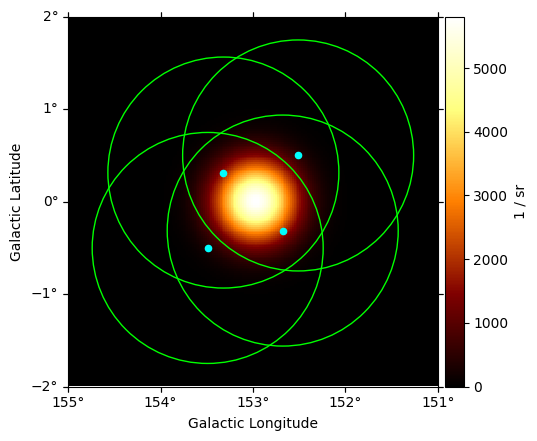

In [6]:
plt.figure()

m = Map.create(skydir=(153, 0), width=(4, 4), binsz=0.02, frame="galactic")
m.quantity = gauss.evaluate_geom(m.geom)
ax = m.plot(add_cbar=True)

pos1pix = pos1.transform_to(frame="galactic").to_pixel(ax.wcs)
pos2pix = pos2.transform_to(frame="galactic").to_pixel(ax.wcs)
pos3pix = pos3.transform_to(frame="galactic").to_pixel(ax.wcs)
pos4pix = pos4.transform_to(frame="galactic").to_pixel(ax.wcs)
# ax = gauss.plot(add_cbar=True)
ax.scatter(pos1pix[0],pos1pix[1],s=20,c="cyan")
ax.scatter(pos2pix[0],pos2pix[1],s=20,c="cyan")
ax.scatter(pos3pix[0],pos3pix[1],s=20,c="cyan")
ax.scatter(pos4pix[0],pos4pix[1],s=20,c="cyan")

# region = gauss_elongated.to_region()
obs1_pix = obs1.to_pixel(ax.wcs)
ax.add_artist(obs1_pix.as_artist(ec="lime", fc="None"))
obs2_pix = obs2.to_pixel(ax.wcs)
ax.add_artist(obs2_pix.as_artist(ec="lime", fc="None"))
obs3_pix = obs3.to_pixel(ax.wcs)
ax.add_artist(obs3_pix.as_artist(ec="lime", fc="None"))
obs4_pix = obs4.to_pixel(ax.wcs)
ax.add_artist(obs4_pix.as_artist(ec="lime", fc="None"))
# plt.show()

# plt.savefig("WobblePointing.png")

The galactic plane can be complex - perhaps a better approach would be to use a grid of pointings. 
We define a grid based on the radius adopted above and with ~1 degree offset between the rows. 

Due to the radial gradient of acceptance, it is better to have every other row offset. 

In [7]:
grid_pos = []
loff = [-1.5,-0.5,0.5,1.5]
boff = [1.5,0.5,-0.5,-1.5]
for i in range(len(boff)):
    plat = 0.+boff[i]*radius.deg
    for j in range(len(loff)):
        plon = 153.+loff[j]*radius.deg
        if i % 2:
            plon = 153.+(loff[j]+0.5)*radius.deg
        grid_pos.append(SkyCoord(plon,plat,unit='deg',frame="galactic"))
        
print(grid_pos)

[<SkyCoord (Galactic): (l, b) in deg
    (151.125, 1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (152.375, 1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (153.625, 1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (154.875, 1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (151.75, 0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (153., 0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (154.25, 0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (155.5, 0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (151.125, -0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (152.375, -0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (153.625, -0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (154.875, -0.625)>, <SkyCoord (Galactic): (l, b) in deg
    (151.75, -1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (153., -1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (154.25, -1.875)>, <SkyCoord (Galactic): (l, b) in deg
    (155.5, -1.875)>]


done 15 observation positions


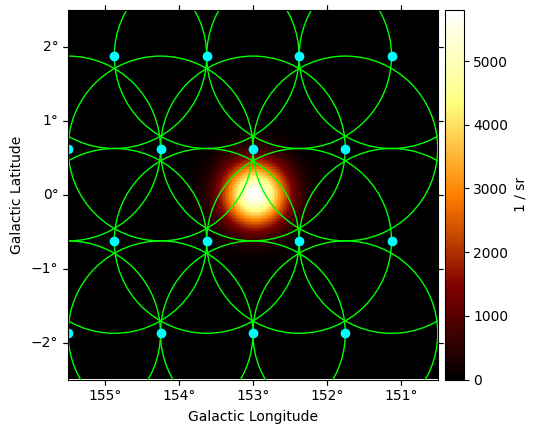

In [8]:
plt.figure()

m = Map.create(skydir=(153, 0), width=(5, 5), binsz=0.02, frame="galactic")
m.quantity = gauss.evaluate_geom(m.geom)
ax2 = m.plot(add_cbar=True)

ppix = np.zeros((len(grid_pos),2))
for pi in range(len(grid_pos)):
    ppix[pi] = grid_pos[pi].to_pixel(ax2.wcs)
    obs_pos = CircleSkyRegion(grid_pos[pi],radius)
    obs_pix = obs_pos.to_pixel(ax2.wcs)
    ax2.add_artist(obs_pix.as_artist(ec="lime", fc="None"))
    
print("done",pi,"observation positions")
ax2.scatter(ppix.T[0],ppix.T[1],c="cyan")

# plt.savefig("GridPointing.png")

None

**Task**: Try plotting a source with similar characteristics to the one you hope to observe and designing an appropriate observation strategy. 

Try also exploring different source geometries (ellipse, elongated) 